<a href="https://www.kaggle.com/code/sonawanelalitsunil/stock-prices-2014-2024-ml-66?scriptVersionId=233242538" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/multiple-stock-price-2014-2024/data.csv


## Title:  Stock Prices (2014–2024)

### Description: Historical price trends of multiple stocks from 2014 to 2024 for comparative analysis and investment insights.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/multiple-stock-price-2014-2024/data.csv')

In [3]:
df.head()

,Date,Close/Last,Volume,Open,PPI,Industry_type,CPI,FEDFUNDS,Unemployment_Rate,GDP,Month,DayOfWeek,DayOfMonth,WeekOfYear,next_day_open_price
0,11/26/2014,39.850,6193752,40.060,210.0,restaurants,-0.562499,0.115000,5.6,17.93,11,2,26,48,40.215
1,11/28/2014,40.605,6766674,40.215,210.0,restaurants,-0.564303,0.117000,5.6,17.93,11,4,28,48,40.500
2,12/1/2014,40.425,8594036,40.500,208.5,restaurants,-0.567010,0.120000,5.6,17.93,12,0,1,49,40.345
3,12/2/2014,40.185,7639786,40.345,208.5,restaurants,-0.563900,0.119677,5.6,17.93,12,1,2,49,40.210
4,12/3/2014,40.235,11201316,40.210,208.5,restaurants,-0.560789,0.119355,5.6,17.93,12,2,3,49,40.300


In [4]:
df.tail()

,Date,Close/Last,Volume,Open,PPI,Industry_type,CPI,FEDFUNDS,Unemployment_Rate,GDP,Month,DayOfWeek,DayOfMonth,WeekOfYear,next_day_open_price
9311,2/23/2024,583.56,2568852,586.40,129.083,video,0.639791,5.33,3.8,28.63,2,4,23,8,583.56
9312,2/26/2024,587.65,2393712,583.56,129.083,video,0.642631,5.33,3.8,28.66,2,0,26,9,595.00
9313,2/27/2024,601.67,4489355,595.00,129.083,video,0.643577,5.33,3.8,28.67,2,1,27,9,595.79
9314,2/28/2024,596.48,2605242,595.79,129.083,video,0.644524,5.33,3.8,28.68,2,2,28,9,604.25
9315,2/29/2024,602.92,3572082,604.25,129.083,video,0.645470,5.33,3.8,28.69,2,3,29,9,599.81


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9316 entries, 0 to 9315
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 9316 non-null   object 
 1   Close/Last           9316 non-null   float64
 2   Volume               9316 non-null   int64  
 3   Open                 9316 non-null   float64
 4   PPI                  9316 non-null   float64
 5   Industry_type        9316 non-null   object 
 6   CPI                  9316 non-null   float64
 7   FEDFUNDS             9316 non-null   float64
 8   Unemployment_Rate    9316 non-null   float64
 9   GDP                  9316 non-null   float64
 10  Month                9316 non-null   int64  
 11  DayOfWeek            9316 non-null   int64  
 12  DayOfMonth           9316 non-null   int64  
 13  WeekOfYear           9316 non-null   int64  
 14  next_day_open_price  9316 non-null   float64
dtypes: float64(8), int64(5), object(2)
mem

In [6]:
df.describe()

,Close/Last,Volume,Open,PPI,CPI,FEDFUNDS,Unemployment_Rate,GDP,Month,DayOfWeek,DayOfMonth,WeekOfYear,next_day_open_price
count,9316.000000,9.316000e+03,9316.000000,9316.000000,9316.000000,9316.000000,9316.000000,9316.000000,9316.000000,9316.000000,9316.000000,9316.000000,9316.000000
mean,118.509973,1.538631e+08,118.477008,158.885684,0.248835,1.485510,4.741048,20.274208,6.512666,2.026621,15.747960,26.492057,118.566488
std,138.699182,2.328276e+08,138.717266,68.651877,0.328217,1.651499,1.735764,5.549604,3.485781,1.396929,8.767947,15.216881,138.796468
min,0.478400,1.143952e+06,0.481300,53.800000,-0.668694,0.050000,3.400000,8.740000,1.000000,0.000000,1.000000,1.000000,0.481300
25%,27.965000,7.379372e+06,27.942500,107.585750,0.026139,0.120000,3.700000,18.380000,3.000000,1.000000,8.000000,13.000000,27.946875
50%,64.320000,4.186576e+07,64.196250,172.700000,0.228619,0.908000,4.200000,21.100000,7.000000,2.000000,16.000000,26.000000,64.281250
75%,143.260000,2.203206e+08,143.292500,203.200000,0.443231,2.199677,5.000000,24.050000,10.000000,3.000000,23.000000,40.000000,143.385000
max,691.690000,3.688132e+09,692.350000,274.798000,1.373608,5.330000,14.800000,28.690000,12.000000,4.000000,31.000000,53.000000,692.350000


In [7]:
df.isnull().sum()

Date                   0
Close/Last             0
Volume                 0
Open                   0
PPI                    0
Industry_type          0
CPI                    0
FEDFUNDS               0
Unemployment_Rate      0
GDP                    0
Month                  0
DayOfWeek              0
DayOfMonth             0
WeekOfYear             0
next_day_open_price    0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Date                    object
Close/Last             float64
Volume                   int64
Open                   float64
PPI                    float64
Industry_type           object
CPI                    float64
FEDFUNDS               float64
Unemployment_Rate      float64
GDP                    float64
Month                    int64
DayOfWeek                int64
DayOfMonth               int64
WeekOfYear               int64
next_day_open_price    float64
dtype: object

In [10]:
df.shape

(9316, 15)

In [11]:
df.columns

Index(['Date', 'Close/Last', 'Volume', 'Open', 'PPI', 'Industry_type', 'CPI',
       'FEDFUNDS', 'Unemployment_Rate', 'GDP', 'Month', 'DayOfWeek',
       'DayOfMonth', 'WeekOfYear', 'next_day_open_price'],
      dtype='object')

## Data visualizations

In [12]:
df['Date'] = pd.to_datetime(df['Date'])

# Optional: Sort by date
df.sort_values('Date', inplace=True)

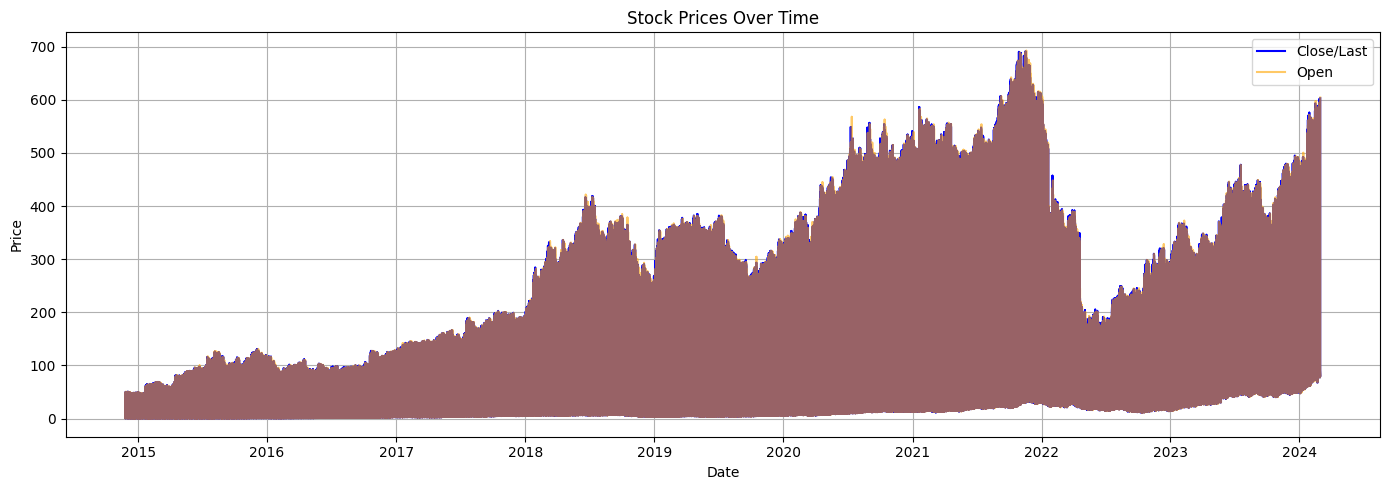

In [13]:
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['Close/Last'], label='Close/Last', color='blue')
plt.plot(df['Date'], df['Open'], label='Open', color='orange', alpha=0.6)
plt.title('Stock Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


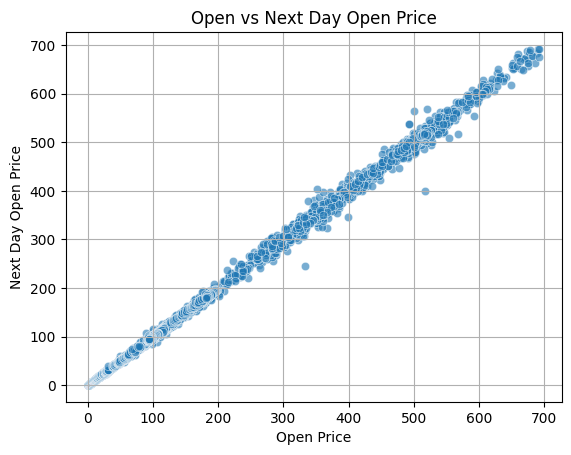

In [14]:
sns.scatterplot(x='Open', y='next_day_open_price', data=df, alpha=0.6)
plt.title('Open vs Next Day Open Price')
plt.xlabel('Open Price')
plt.ylabel('Next Day Open Price')
plt.grid(True)
plt.show()


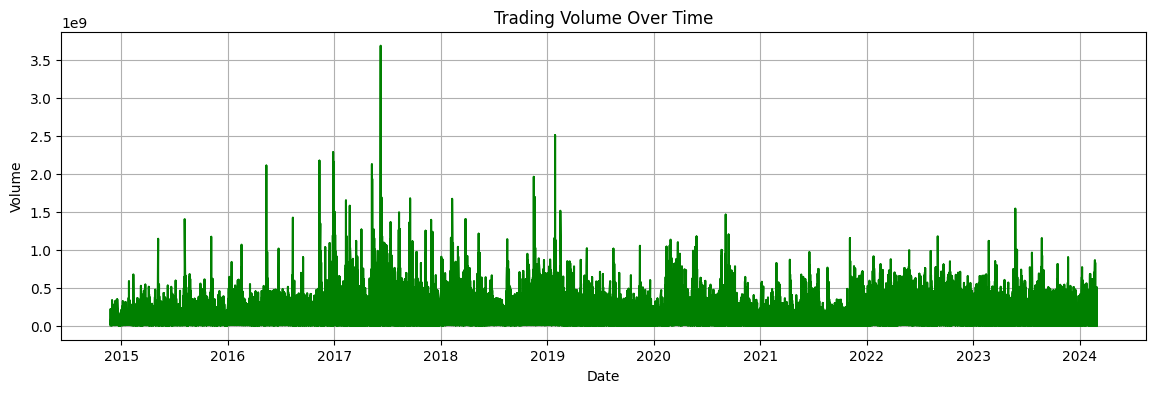

In [15]:
plt.figure(figsize=(14, 4))
plt.plot(df['Date'], df['Volume'], color='green')
plt.title('Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True)
plt.show()


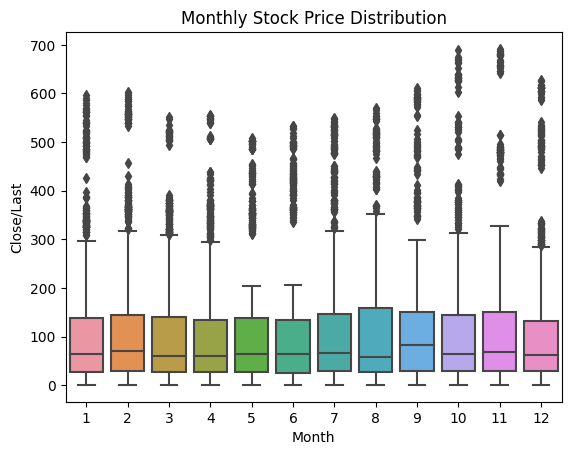

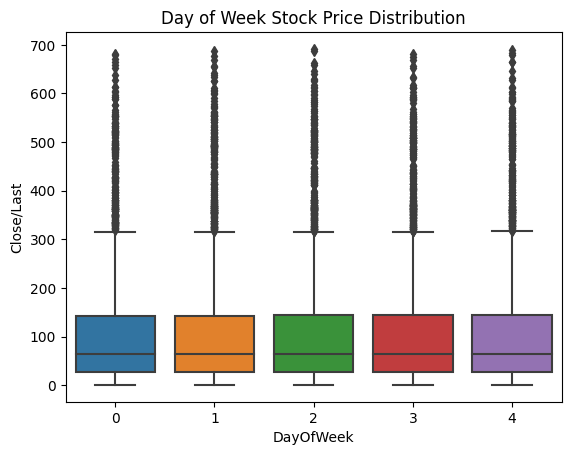

In [16]:
# Monthly
sns.boxplot(x='Month', y='Close/Last', data=df)
plt.title('Monthly Stock Price Distribution')
plt.show()

# Day of Week
sns.boxplot(x='DayOfWeek', y='Close/Last', data=df)
plt.title('Day of Week Stock Price Distribution')
plt.show()


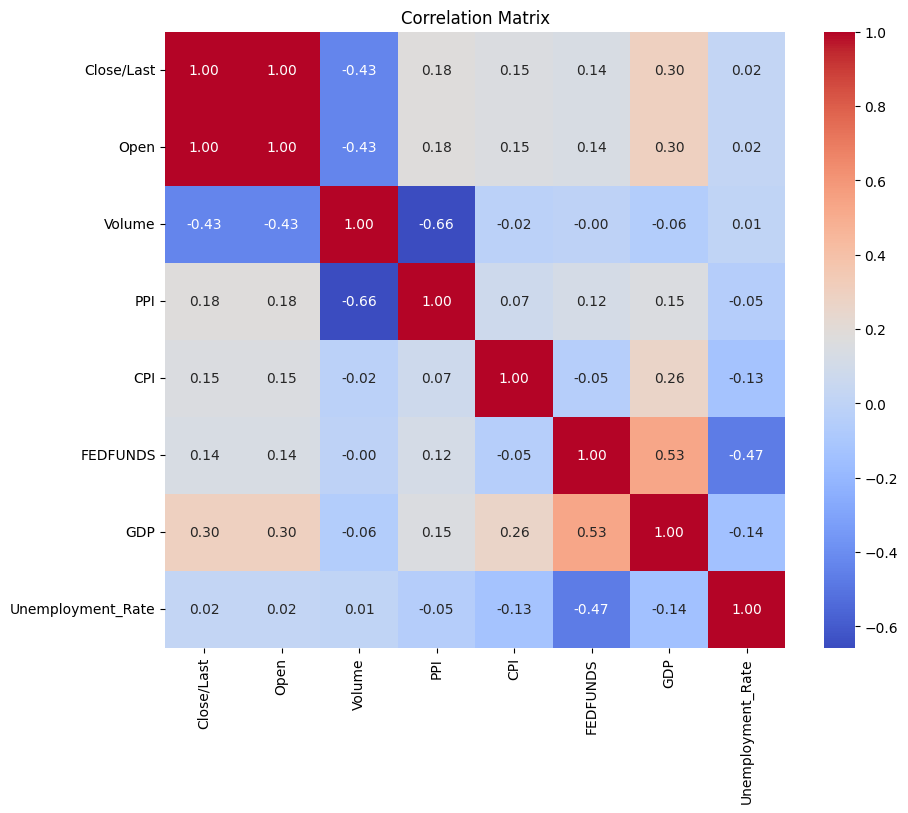

In [17]:
plt.figure(figsize=(10, 8))
corr = df[['Close/Last', 'Open', 'Volume', 'PPI', 'CPI', 'FEDFUNDS', 'GDP', 'Unemployment_Rate']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


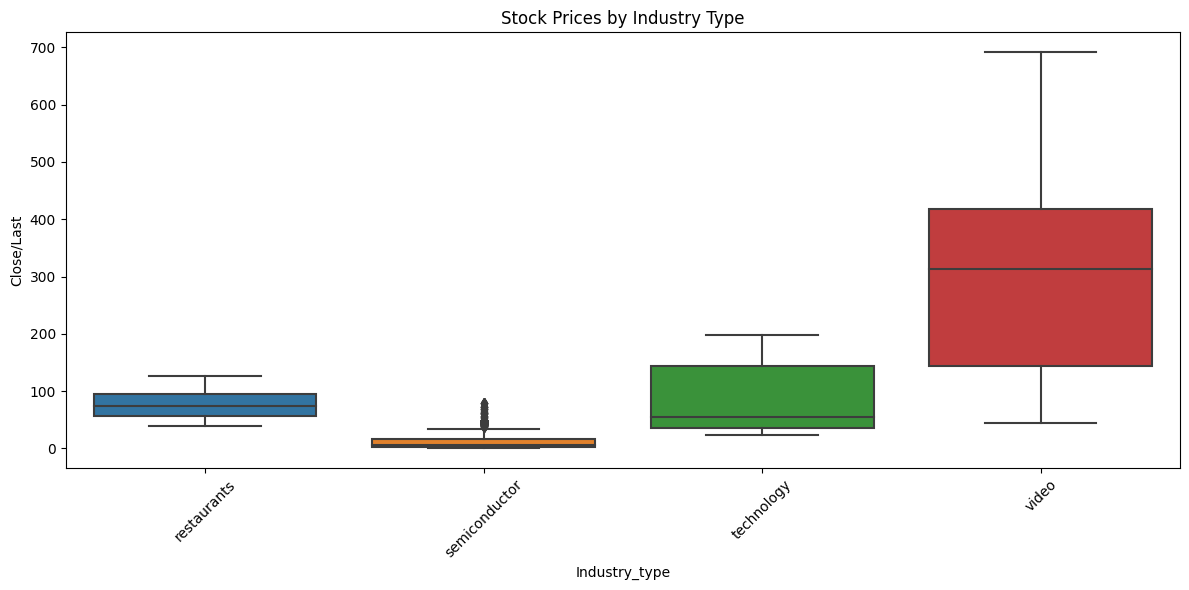

In [18]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Industry_type', y='Close/Last', data=df)
plt.title('Stock Prices by Industry Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



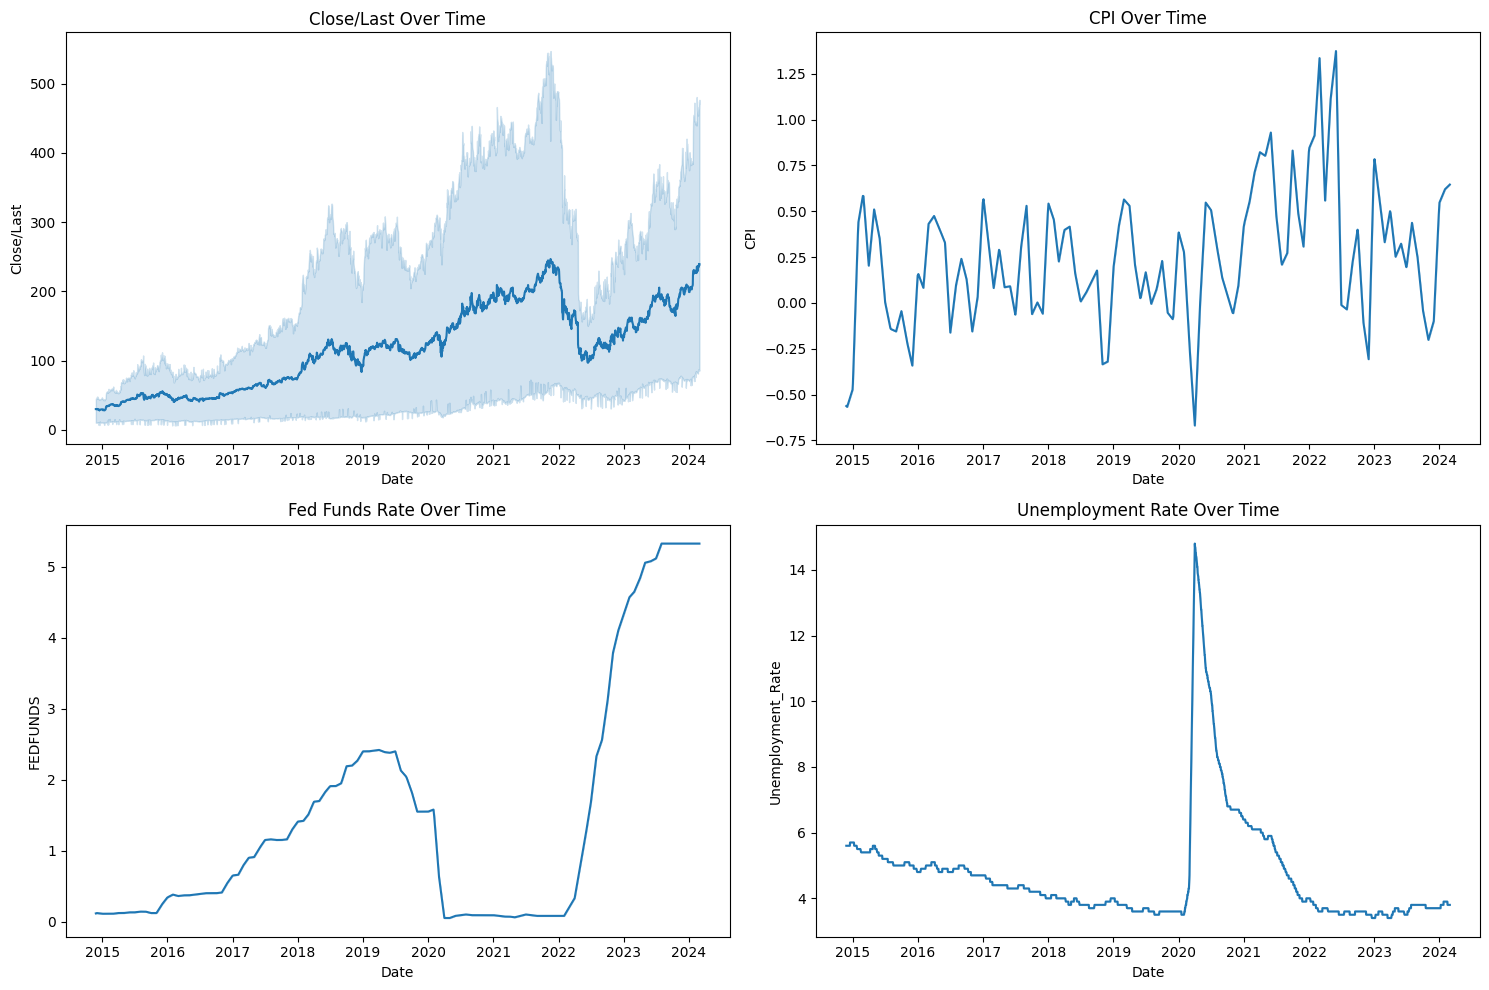

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.lineplot(x='Date', y='Close/Last', data=df, ax=axes[0,0]).set(title='Close/Last Over Time')
sns.lineplot(x='Date', y='CPI', data=df, ax=axes[0,1]).set(title='CPI Over Time')
sns.lineplot(x='Date', y='FEDFUNDS', data=df, ax=axes[1,0]).set(title='Fed Funds Rate Over Time')
sns.lineplot(x='Date', y='Unemployment_Rate', data=df, ax=axes[1,1]).set(title='Unemployment Rate Over Time')
plt.tight_layout()
plt.show()


## Predictive modeling

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [22]:
df['Date'] = pd.to_datetime(df['Date'])

In [23]:
df.drop('Date', axis=1, inplace=True)

In [24]:
df.dropna(inplace=True)

In [25]:
df['Target'] = (df['next_day_open_price'] > df['Open']).astype(int)

In [26]:
# Drop 'next_day_open_price' from features
df.drop('next_day_open_price', axis=1, inplace=True)

In [27]:
label_cols = ['Industry_type', 'DayOfWeek']  # Modify if you have more categorical columns
le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])

In [28]:
X = df.drop('Target', axis=1)
y = df['Target']

In [29]:
# Feature Scaling (important for SVM, KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [30]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [31]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier()
}

In [32]:
for name, model in models.items():
    print(f"\n=== {name} ===")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", round(acc, 4))
    print("Classification Report:\n", classification_report(y_test, y_pred))



=== Logistic Regression ===
Accuracy: 0.6561
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.32      0.47       878
           1       0.61      0.96      0.75       986

    accuracy                           0.66      1864
   macro avg       0.74      0.64      0.61      1864
weighted avg       0.73      0.66      0.61      1864


=== Random Forest ===
Accuracy: 0.5451
Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.49      0.51       878
           1       0.57      0.59      0.58       986

    accuracy                           0.55      1864
   macro avg       0.54      0.54      0.54      1864
weighted avg       0.54      0.55      0.54      1864


=== Gradient Boosting ===
Accuracy: 0.5933
Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.32      0.42       878
           1       0.58      0.84  

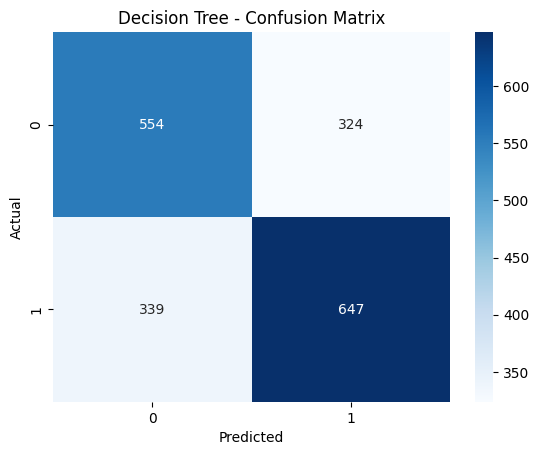

In [33]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"{name} - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Thank you...pls upvote!!!!